# 06 · GeoAI, spatial validation, and world models

**Decision question.** When does a fitted spatial relationship fail to generalize, and how is prediction different from scenario simulation?

**Time:** 30–45 minutes. **Prerequisites:** basic Python arrays and tables. Run cells from top to bottom.
The shared `rewiring.py` module must stay beside the notebooks. Initial package downloads require internet;
the core calculations use reproducible synthetic data. No health-service credentials are needed.

**Data contract:** the fictional grid is geographically anchored near Gaborone for teaching map coordinates.
Its people, facilities, climate, events, and model parameters are invented. It is **not a map of actual
Gaborone disease, vulnerability, buildings, or care access**. Satellite catalog metadata, when used, is labeled separately.

[Book](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/) · [Interactive demo gallery](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) · [Data and credits](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/DATA_SOURCES.md)

In [1]:
import sys
if sys.platform == 'emscripten':
    import micropip
    await micropip.install(['numpy', 'pandas', 'matplotlib'])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, IFrame
from rewiring import (city, long_table, map_image, map_matrix, geojson,
                      leaflet, save_export, simulate_twin, teaching_review, HATS, SITE, LABEL, EXTENT)
plt.rcParams.update({'figure.dpi': 105, 'axes.spines.top': False, 'axes.spines.right': False})
cells, cube = city()
panel = long_table(cells, cube)
print(LABEL)
print('Python', sys.version.split()[0], '| cells:', len(cells), '| monthly observations:', len(panel))

SYNTHETIC teaching data · not observations or a forecast
Python 3.13.14 | cells: 64 | monthly observations: 1536


## Learn a relationship, then test it outside its training geography

GeoAI combines geographic structure with machine learning. We fit a small linear model using NumPy so
every assumption is inspectable. The target is a generated event rate, not a diagnosis. Train on the
western half and test on the eastern half; a random split mixes nearby cells and can hide spatial shift.
This one split is an illustration, not a sufficient validation design for deployment.

In [2]:
table=cells.copy()
table['heat_c']=cube['heat_c'].mean(axis=0).ravel()
table['target']=cube['rate_per_1000'].mean(axis=0).ravel()
X=np.c_[np.ones(len(table)),table[['heat_c','access_min','vulnerability']].to_numpy()]
y=table.target.to_numpy()
west=table.col.to_numpy()<4
coef=np.linalg.lstsq(X[west],y[west],rcond=None)[0]
prediction=X@coef
mae=lambda a,b: float(np.mean(np.abs(a-b)))
display(pd.Series(coef,index=['intercept','heat_c','access_min','vulnerability'],name='Fitted coefficients'))
print('West training MAE:',round(mae(y[west],prediction[west]),3))
print('East held-out MAE:',round(mae(y[~west],prediction[~west]),3))

intercept       -30.130411
heat_c            1.507174
access_min        0.029574
vulnerability     6.195189
Name: Fitted coefficients, dtype: float64

West training MAE: 0.614
East held-out MAE: 0.894


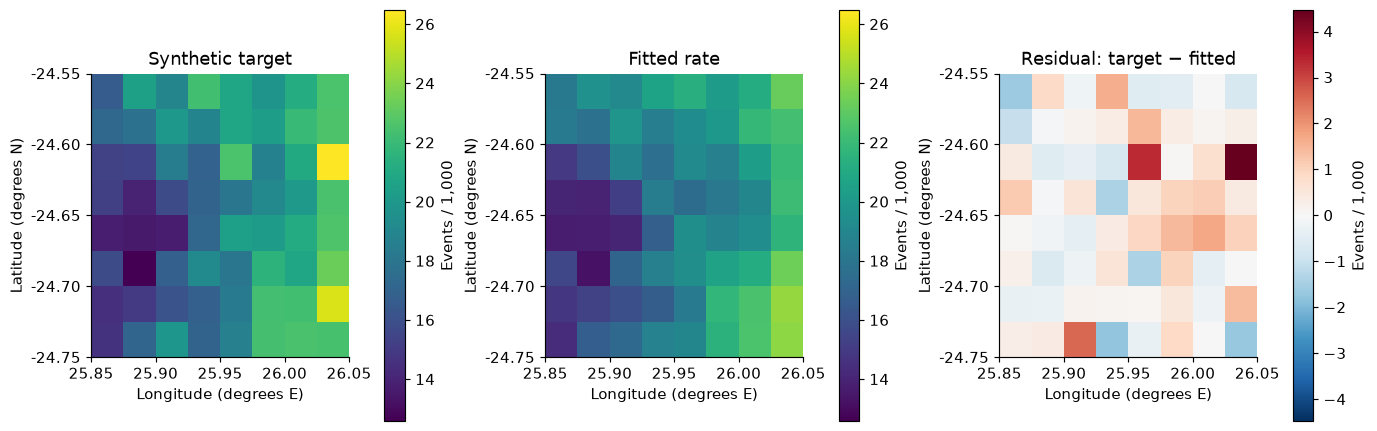

In [3]:
residual=y-prediction
fig,axes=plt.subplots(1,3,figsize=(13,4),layout='constrained')
for ax,z,title in zip(axes,[y,prediction,residual],['Synthetic target','Fitted rate','Residual: target − fitted']):
    limits=(-np.abs(residual).max(),np.abs(residual).max()) if title.startswith('Residual') else (min(y.min(),prediction.min()),max(y.max(),prediction.max()))
    im=map_image(ax,z.reshape(8,8),title,*limits,cmap='RdBu_r' if title.startswith('Residual') else 'viridis')
    fig.colorbar(im,ax=ax,label='Events / 1,000')
plt.show()

## Baselines and failure modes

Compare a learned model against a training-mean baseline. Then introduce a synthetic east-side reporting
shift. A model can predict the training process well and still fail when measurement or service access
changes. A high score is not sufficient evidence of portability, calibration, equity, or causal meaning.

In [4]:
rng=np.random.default_rng(6)
random_train=rng.random(len(table))<.5
random_coef=np.linalg.lstsq(X[random_train],y[random_train],rcond=None)[0]
shifted=y.copy(); shifted[~west]+=6
metrics=pd.DataFrame({'evaluation':['East: mean baseline','East: spatial holdout','Random holdout','East: reporting shift'],
 'MAE':[mae(y[~west],np.repeat(y[west].mean(),(~west).sum())),mae(y[~west],prediction[~west]),
        mae(y[~random_train],(X@random_coef)[~random_train]),mae(shifted[~west],prediction[~west])]})
display(metrics)

,evaluation,MAE
0,East: mean baseline,4.602968
1,East: spatial holdout,0.894404
2,Random holdout,0.843416
3,East: reporting shift,6.527406


## A grounded world model needs a transition and an observation model

Represent state as heat, access, and vulnerability; define an action; specify how state changes; and
separately specify how measurements arise. Below the transition is hand-written and coefficients vary
across an ensemble. It is **not a learned foundation world model** and its action effects are assumptions.

![State, action, transition, observation, and evaluation](assets/world-model.svg)

A frontier research question is how learned spatial representations can support physically and socially
plausible transitions while preserving uncertainty, local knowledge, and human agency.

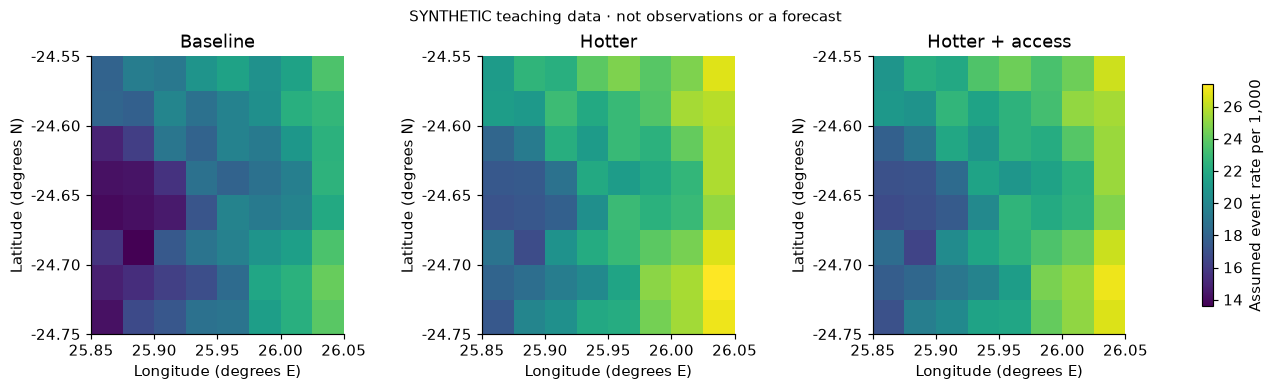

In [5]:
def transition(state, heat_delta=0, access_delta=0):
    future=state.copy()
    future['heat_c']+=heat_delta
    future['access_min']=np.maximum(5,future.access_min+access_delta)
    return future
scenarios={'Baseline':transition(table),'Hotter':transition(table,heat_delta=2),
           'Hotter + access':transition(table,heat_delta=2,access_delta=-15)}
def assumed_burden(state,heat_effect=1.6):
    return np.maximum(0,8+heat_effect*(state.heat_c-25)+6*state.vulnerability+.025*state.access_min)
surfaces=[assumed_burden(s).to_numpy().reshape(8,8) for s in scenarios.values()]
map_matrix(surfaces,list(scenarios),'Assumed event rate per 1,000'); plt.show()

,min,median,max
scenario,,,
Baseline,15.566201,18.880997,22.195794
Hotter,16.766201,22.080997,27.395794
Hotter + access,16.393610,21.708406,27.023203


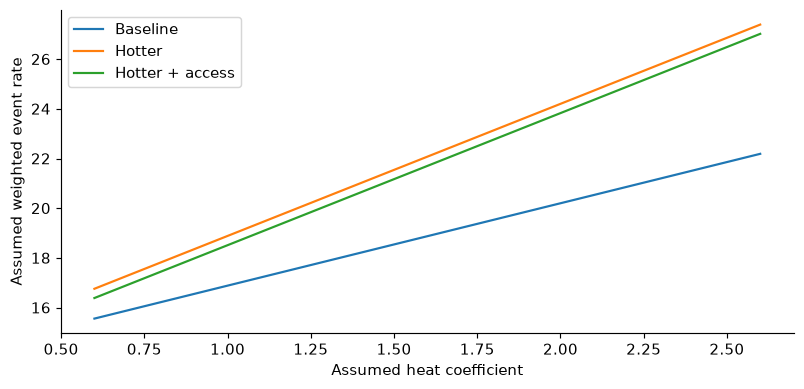

In [6]:
ensemble=[]
for effect in np.linspace(.6,2.6,41):
    for name,state in scenarios.items():
        ensemble.append((name,effect,np.average(assumed_burden(state,effect),weights=state.population)))
ensemble=pd.DataFrame(ensemble,columns=['scenario','assumed_heat_effect','weighted_rate'])
display(ensemble.groupby('scenario').weighted_rate.agg(['min','median','max']))
fig,ax=plt.subplots(figsize=(9,4))
for name,g in ensemble.groupby('scenario'): ax.plot(g.assumed_heat_effect,g.weighted_rate,label=name)
ax.set(xlabel='Assumed heat coefficient',ylabel='Assumed weighted event rate'); ax.legend(); plt.show()

## Investigate, interpret, and discuss

1. Repeat geographic validation by withholding north, south, east, and west in turn.
2. Map missingness and consider which communities a training dataset might underrepresent.
3. Describe the evidence required before interpreting the action transition as a causal effect.
4. Define a physical constraint, a social constraint, and a stopping rule for a learned world model.

**Before sharing:** state the decision, data status, units, denominator, scale, uncertainty, and who can contest the result.
Record what would change your conclusion. Export only information that the intended audience needs.

## Sources and attribution

- [GeoAI project](https://github.com/opengeos/geoai), broader methods and tooling; not a dependency here.
- Ha, D. & Schmidhuber, J. (2018), [World Models](https://worldmodels.github.io/).
- Tobias et al. (2026), supplied Gaborone digital-twin presentation, pp. 4, 16, 21.
- WHO (2021), [ethics and governance guidance](https://www.who.int/publications/i/item/9789240029200).

Original lesson code: MIT. Original narrative, synthetic data, and generated figures: CC BY 4.0.
Third-party data, videos, services, and software retain their own terms.
[Full references](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/REFERENCES.md) · [Third-party notices](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/THIRD_PARTY_NOTICES.md).